# Train Model on Rebalanced Dataset: Random Downsampling of Negative Clips

## Table of Contents
1. Summary
2. Pre-Requisite Knowledge
3. Credit
4. Setup [Installing Dependencies, Importing Libraries, and Notebook Parameters]
5. Balance Training Data
6. Validate Dataset
7. Load Dataset
8. Train Model
9. Evaluate Model on Validation Data

## Summary:
This notebook trains a SRKW call detection model on the Eras 0 & 1 dataset after rebalancing the train set -- by downsampling the negative clips (majority class). The learning is facilitated via the FastAIv2 deep learning library.

## Pre-Requisite Knowledge:
* We refer to PodCast-labeled data as Era0 dataset; no one has generated new data with this tool since ~2019. 
* We refer to OrcaHello-labeled data from 2020-2024 as Era1 dataset; everything here is either true- or false-positive detected by our original production SRKW call detection model and manually-labeled by our team of moderators.

## Credit
This notebook is based on a [model training notebook](https://github.com/orcasound/aifororcas-livesystem/blob/4eaf038404b56ef087a6efaaf670b83206f30ec1/ModelTraining/3_InferenceTesting.ipynb) built with FastAIv1 and updated to FastAIv2 with assistance from [grandebruno](https://github.com/BrunoGrandePhD/BrunoGrandePhD).

## Installing Dependencies

In [1]:
import sys
!{sys.executable} -m pip install -r ../requirements.txt

  Cloning https://github.com/kevinbird15/fastaudio.git (to revision fastaudio_refresh) to /tmp/pip-req-build-vygdzu4o
  Running command git clone --filter=blob:none --quiet https://github.com/kevinbird15/fastaudio.git /tmp/pip-req-build-vygdzu4o
  Running command git checkout -b fastaudio_refresh --track origin/fastaudio_refresh
  Switched to a new branch 'fastaudio_refresh'
  branch 'fastaudio_refresh' set up to track 'origin/fastaudio_refresh'.
  Resolved https://github.com/kevinbird15/fastaudio.git to commit 045a276d227387c630b6aa1a3eba6fae1f6646c4
  Preparing metadata (setup.py) ... done


## Importing Libraries

In [2]:
# Standard lib packages
from collections import Counter
import math
from pathlib import Path
import random
import shutil

# 3rd party packages
import seaborn as sns
import torch
import torchaudio
from tqdm.autonotebook import tqdm

/tmp/ipykernel_4441/3624329443.py:12: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Notebook Parameters

In [3]:
# Absolute path to the orca-ml repo
REPO_ROOT = Path.cwd().parent

# Absolute path to directory where we'll copy in subset of processed data for training
TEMP_DATA_FOLDER = REPO_ROOT / 'data/temp/'

# Random seed for result reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Is GPU available for FastAI
print(f'GPU available for FastAI : {torch.cuda.is_available()}')

GPU available for FastAI : True


## Balance & Move Training Data

In [4]:
# Prepare a temporary folder for rebalanced train set and validation data

trn_temp_pos_rebalanced_data_folder = TEMP_DATA_FOLDER / 'train/positive'
trn_temp_neg_rebalanced_data_folder = TEMP_DATA_FOLDER / 'train/negative'

trn_temp_pos_rebalanced_data_folder.mkdir(parents=True, exist_ok=True)
trn_temp_neg_rebalanced_data_folder.mkdir(parents=True, exist_ok=True)

val_temp_pos_data_folder = TEMP_DATA_FOLDER / 'val/positive'
val_temp_neg_data_folder = TEMP_DATA_FOLDER / 'val/negative'

val_temp_pos_data_folder.mkdir(parents=True, exist_ok=True)
val_temp_neg_data_folder.mkdir(parents=True, exist_ok=True)

### Era 0

In [8]:
era0_pos_train_data_folder = REPO_ROOT / 'data/era0/train/positive'
era0_neg_train_data_folder = REPO_ROOT / 'data/era0/train/negative'

if not era0_pos_train_data_folder.exists() or not era0_neg_train_data_folder.exists():
    raise Exception("Era 0 train set not found; run 1a_GenerateDataEra0.ipynb")

# Load all positive and negative clip filepaths into memory
era0_all_pos_train_clips = list(era0_pos_train_data_folder.rglob("*.wav"))
era0_all_neg_train_clips = list(era0_neg_train_data_folder.rglob("*.wav"))
if len(era0_all_pos_train_clips) < 1 or len(era0_all_neg_train_clips) < 1:
    raise Exception("Era 0 train set not found; run 1a_GenerateDataEra0.ipynb")

# Balance distribution of clips between positive and negative via random selection (without replacement)
era0_pos_train_clips = era0_all_pos_train_clips # random.sample(era0_all_pos_train_clips, 1000)
era0_neg_train_clips = random.sample(era0_all_neg_train_clips, len(era0_pos_train_clips))
era0_all_train_clips = era0_pos_train_clips + era0_neg_train_clips

# Copy positive training clips to temp folder for use in training
for file in era0_pos_train_clips:
    try:
        torchaudio.info(file)
        shutil.copy(file, trn_temp_pos_rebalanced_data_folder / file.name)
    except RuntimeError:
        print(f"Could not decode audio file {str(file)}")

# Copy negative training clips to temp folder for use in training
for file in era0_neg_train_clips:
    try:
        torchaudio.info(file)
        shutil.copy(file, trn_temp_neg_rebalanced_data_folder / file.name)
    except RuntimeError:
        print(f"Could not decode audio file {str(file)}")

era0_pos_val_data_folder = REPO_ROOT / 'data/era0/val/positive'
era0_neg_val_data_folder = REPO_ROOT / 'data/era0/val/negative'

if not era0_pos_val_data_folder.exists() or not era0_neg_val_data_folder.exists():
    raise Exception("Era 0 validation set not found; run 1a_GenerateDataEra0.ipynb")

# Load all positive and negative clip filepaths into memory
era0_all_pos_val_clips = list(era0_pos_val_data_folder.rglob("*.wav"))
era0_all_neg_val_clips = list(era0_neg_val_data_folder.rglob("*.wav"))
if len(era0_all_pos_val_clips) < 1 or len(era0_all_neg_val_clips) < 1:
    raise Exception("Era 0 train set not found; run 1a_GenerateDataEra0.ipynb")

# Balance distribution of clips between positive and negative via random selection (without replacement)
era0_pos_val_clips = era0_all_pos_val_clips
era0_neg_val_clips = era0_all_neg_val_clips
era0_all_val_clips = era0_pos_val_clips + era0_neg_val_clips

# Copy positive training clips to temp folder for use in training
for file in era0_pos_val_clips:
    try:
        torchaudio.info(file)
        shutil.copy(file, val_temp_pos_data_folder / file.name)
    except RuntimeError:
        print(f"Could not decode audio file {str(file)}")

# Copy negative training clips to temp folder for use in training
for file in era0_neg_val_clips:
    try:
        torchaudio.info(file)
        shutil.copy(file, val_temp_neg_data_folder / file.name)
    except RuntimeError:
        print(f"Could not decode audio file {str(file)}")

### Era 1

In [5]:
# 1000 ~89%
# 2000 ~92%

pos_train_data_folder = REPO_ROOT / 'data/processed/train/positive'
neg_train_data_folder = REPO_ROOT / 'data/processed/train/negative'

if not pos_train_data_folder.exists() or not neg_train_data_folder.exists():
    raise Exception("Train set not found; run 1*_GenerateDataEra*.ipynb")

# Load all positive and negative clip filepaths into memory
all_pos_train_clips = list(pos_train_data_folder.rglob("*.wav"))
all_neg_train_clips = list(neg_train_data_folder.rglob("*.wav"))
if len(all_pos_train_clips) < 1 or len(all_neg_train_clips) < 1:
    raise Exception("Train set not found; run 1*_GenerateDataEra*.ipynb")

# Balance distribution of clips between positive and negative via random selection (without replacement)
pos_train_clips = all_pos_train_clips # random.sample(all_pos_train_clips, 1000)
neg_train_clips = random.sample(all_neg_train_clips, len(pos_train_clips))
all_train_clips = pos_train_clips + neg_train_clips

# Populate our temp folder with rebalanced train set
temp_pos_rebalanced_data_folder = TEMP_DATA_FOLDER / 'train/positive'
temp_neg_rebalanced_data_folder = TEMP_DATA_FOLDER / 'train/negative'
temp_pos_rebalanced_data_folder.mkdir(parents=True, exist_ok=True)
temp_neg_rebalanced_data_folder.mkdir(parents=True, exist_ok=True)

# Copy positive training clips to temp folder for use in training
for file in pos_train_clips:
    try:
        torchaudio.info(file)
        shutil.copy(file, temp_pos_rebalanced_data_folder / file.name)
    except RuntimeError:
        print(f"Could not decode audio file {str(file)}")

# Copy negative training clips to temp folder for use in training
for file in neg_train_clips:
    try:
        torchaudio.info(file)
        shutil.copy(file, temp_neg_rebalanced_data_folder / file.name)
    except RuntimeError:
        print(f"Could not decode audio file {str(file)}")

Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/Users/patrick.j.pastore/orca-ml/data/processed/train/positive/k1_conf0.987_rpi_bush_point_2021_12_01_11_58_12_PST.wav_OfficialEra1.wav
Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/Users/patrick.j.pastore/orca-ml/data/processed/train/positive/k1_conf0.993_rpi_bush_point_2020_12_08_20_44_31_PST.wav_OfficialEra1.wav
Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/Users/patrick.j.pastore/orca-ml/data/processed/train/positive/k1_conf0.996_rpi_bush_point_2021_12_01_11_44_26_PST.wav_OfficialEra1.wav
Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/Users/patrick.j.pastore/orca-ml/data/processed/train/positive/k1_conf0.99_rpi_port_townsend_2020_11_29_15_21_23_PST.wav_OfficialEra1.wav
Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt

## Move Validation Data

In [6]:
pos_val_data_folder = REPO_ROOT / 'data/processed/val/positive'
neg_val_data_folder = REPO_ROOT / 'data/processed/val/negative'

if not pos_val_data_folder.exists() or not neg_val_data_folder.exists():
    raise Exception("Validation set not found; run 1*_GenerateDataEra*.ipynb")

# Load all positive and negative clip filepaths into memory
pos_val_clips = list(pos_val_data_folder.rglob("*.wav"))
neg_val_clips = list(neg_val_data_folder.rglob("*.wav"))
if len(pos_val_clips) < 1 or len(neg_val_clips) < 1:
    raise Exception("Validation set not found; run 1*_GenerateDataEra*.ipynb")

# Copy positive validation clips to temp folder for use in training
for file in pos_val_clips:
    try:
        torchaudio.info(file)
        shutil.copy(file, val_temp_pos_data_folder / file.name)
    except RuntimeError:
        print(f"Could not decode audio file {str(file)}")

# Copy negative validation clips to temp folder for use in training
for file in neg_val_clips:
    try:
        torchaudio.info(file)
        shutil.copy(file, val_temp_neg_data_folder / file.name)
    except RuntimeError:
        print(f"Could not decode audio file {str(file)}")

Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/Users/patrick.j.pastore/orca-ml/data/processed/val/positive/k10_conf0.564_rpi_bush_point_2022_11_10_18_52_40_PST.wav_OfficialEra1.wav
Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/Users/patrick.j.pastore/orca-ml/data/processed/val/positive/k10_conf0.81_rpi_bush_point_2022_11_10_18_59_40_PST.wav_OfficialEra1.wav
Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/Users/patrick.j.pastore/orca-ml/data/processed/val/positive/k14_conf0.715_rpi_bush_point_2022_11_10_18_55_40_PST.wav_OfficialEra1.wav
Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/Users/patrick.j.pastore/orca-ml/data/processed/val/positive/k15_conf0.597_rpi_bush_point_2022_11_10_19_37_40_PST.wav_OfficialEra1.wav
Could not decode audio file /mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/

### Dataset Size Sanity Check

In [7]:
print(f'{len(list(pos_train_data_folder.rglob("*.wav")))} positive (SRKW call) clips in original train set')
print(f'{len(list(neg_train_data_folder.rglob("*.wav")))} negative (not SRKW call) clips in original train set')
print()
print(f'{len(list(temp_pos_rebalanced_data_folder.rglob("*.wav")))} positive (SRKW call) clips in rebalanced train set')
print(f'{len(list(temp_neg_rebalanced_data_folder.rglob("*.wav")))} negative (not SRKW call) clips in rebalanced train set')
print()
print(f'{len(list(pos_val_data_folder.rglob("*.wav")))} positive (SRKW call) clips in validation set')
print(f'{len(list(neg_val_data_folder.rglob("*.wav")))} negative (not SRKW call) clips in validation set')

5679 positive (SRKW call) clips in original train set
25872 negative (not SRKW call) clips in original train set

8021 positive (SRKW call) clips in rebalanced train set
8007 negative (not SRKW call) clips in rebalanced train set

1219 positive (SRKW call) clips in validation set
8549 negative (not SRKW call) clips in validation set


In [8]:
def extract_metadata(items: list[Path]):
    """Extract audio metadata from each file."""
    metadata = dict()
    for item in tqdm(items):
        metadata[item] = torchaudio.info(item)
    
    sample_rates = Counter(x.sample_rate for x in metadata.values())
    num_channels = Counter(x.num_channels for x in metadata.values())
    print("Sample Rates:")
    for rate, count in sample_rates.items():
        print(f"- {rate} Hz: {count} files")
    print("Sample Rates:")
    for channels, count in num_channels.items():
        print(f"- {channels} Channels: {count} files")

    return metadata

# TODO: Clean out audio files with only one channel (or just simplify all to single channel)

In [9]:
metadata = extract_metadata(list(temp_pos_rebalanced_data_folder.rglob("*.wav")) + list(temp_neg_rebalanced_data_folder.rglob("*.wav")))

  0%|          | 0/16028 [00:00<?, ?it/s]

Sample Rates:
- 20000 Hz: 4706 files
- 48000 Hz: 11322 files
Sample Rates:
- 1 Channels: 4721 files
- 2 Channels: 11307 files


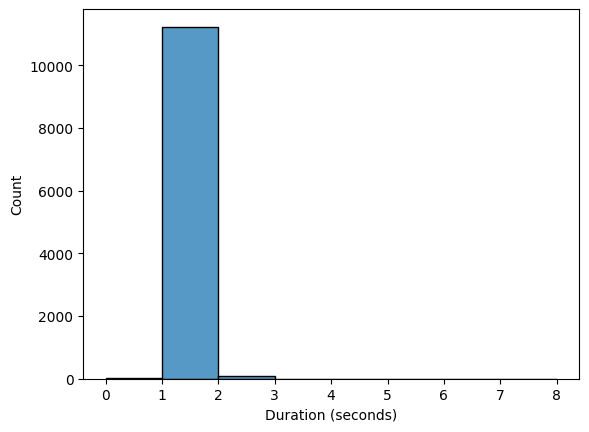

In [ ]:
durations = [x.num_frames / x.sample_rate for x in metadata.values()]

plot = sns.histplot(
    durations, 
    binwidth=1,
    binrange=(0, math.ceil(max(durations)))
).set(xlabel="Duration (seconds)", ylabel="Count")

# TODO: Clean data so all every clip is 1sec < X <= 2sec

## Load Data

One of the key goals of this section is to ensure that the audio files converted into identical images (spectrograms) between v1 and v2.

In [ ]:
all_train_clips = pos_train_clips + neg_train_clips
all_train_clips[0]

Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/gpu-vm-1xt4/code/Users/patrick.j.pastore/orca-ml/data/processed/train/positive/k10_conf0.503_rpi_port_townsend_2020_11_29_15_20_21_PST.wav_OfficialEra1.wav')

In [ ]:
import torchaudio.transforms as T

# Define the torchaudio transforms based on the AudioConfig parameters
transform_spec = T.MelSpectrogram(
    sample_rate=20000,
    f_min=0.0,
    f_max=10000,
    hop_length=256,
    n_fft=2560,
    n_mels=256,
    pad=0,
    win_length=None,
)

# Convert to decibel scale
transform_db = T.AmplitudeToDB(top_db=100)

transform = lambda x: transform_db(transform_spec(x)).detach()

In [ ]:
path = pos_train_clips[2]
signal, sample_rate = torchaudio.load(path)
tensor = transform(signal)

torch.Size([2, 256, 188])


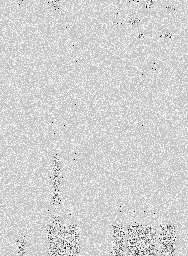

In [ ]:
from torchvision.transforms import functional as F

print(tensor.shape)
image = F.to_pil_image(tensor)
image

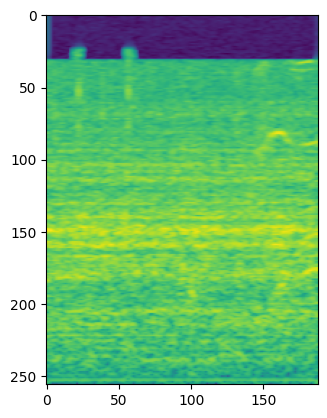

In [ ]:
import matplotlib.pyplot as plt

def show_image(tensor):
    result = F.rotate(tensor, 180)
    result = F.hflip(result)
    result = result.cpu().permute(1,2,0).numpy()
    result = result[...,0] if result.shape[2]==1 else result
    plt.imshow(result[:,:,1])
    
show_image(tensor)

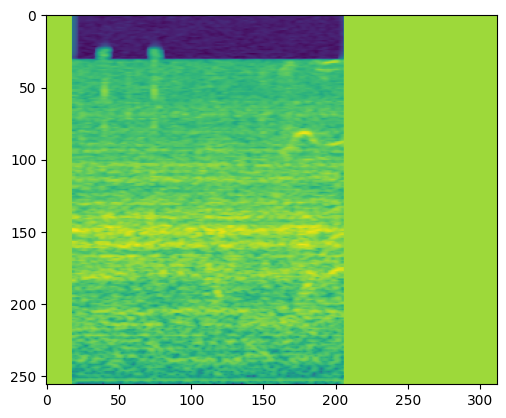

In [ ]:
import torch

class PadOrCropTransform:
    def __init__(self, target_duration, hop):
        self.target_duration = target_duration
        self.hop = hop

    def __call__(self, data, sample_rate):
        output = data.clone()
        num_channels, height, width = output.shape
        target_width = int(sample_rate * self.target_duration / self.hop)

        if width < target_width:  # Pad
            missing_width = target_width - width
            left_pad_width = random.randint(0, missing_width)
            right_pad_width = target_width - width - left_pad_width
            pad_front = torch.zeros((num_channels, height, left_pad_width))
            pad_back = torch.zeros((num_channels, height, right_pad_width))
            output = torch.cat((pad_front, data, pad_back), 2)

        else:  # Crop
            crop_start = random.randint(0, width - target_width)
            output = output[:, :, crop_start:(crop_start + target_width)]

        return output

pad_or_crop = PadOrCropTransform(4, 256)

output = pad_or_crop(tensor, 20000)
show_image(output)

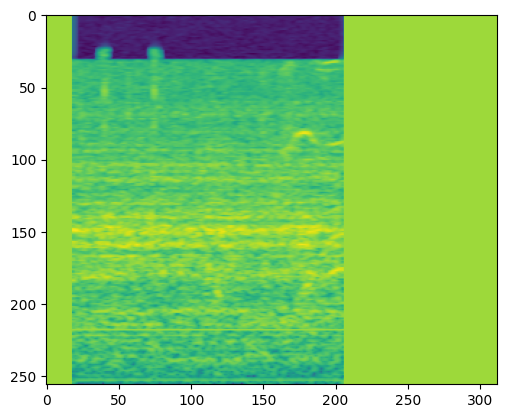

In [ ]:
transform_mask_freq = T.FrequencyMasking(freq_mask_param=30)

show_image(transform_mask_freq(output))

## Model Training

### Approach 1: Creating a data block

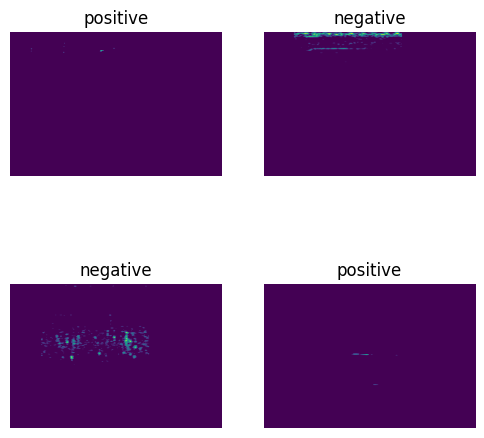

In [ ]:
from fastai.data.block import DataBlock, CategoryBlock
from fastai.data.transforms import GrandparentSplitter
from fastai.vision.all import ImageBlock

def get_audio_files(path):
    return list(path.rglob("*.wav"))

def parent_label(path):
    return path.parent.name

transform_spec = T.MelSpectrogram(
    sample_rate=20000,
    f_min=0.0,
    f_max=10000,
    hop_length=256,
    n_fft=2560,
    n_mels=256,
    pad=0,
    win_length=None,
)
transform_db = T.AmplitudeToDB() # top_db=100)
pad_or_crop = PadOrCropTransform(4, hop=256)
mask_freq = T.FrequencyMasking(freq_mask_param=30)

# Define a function to load and transform the audio data
def load_audio(path):
    signal, sample_rate = torchaudio.load(path)

    spectrogram = transform_db(transform_spec(signal))
    # If multi-channel, take average across samples
    spectrogram = spectrogram.mean(0, keepdim=True)
    spectrogram = pad_or_crop(spectrogram, sample_rate)
    # spectrogram = mask_freq(spectrogram)
    return spectrogram.squeeze(0)

# Create a DataBlock
audio_block = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_audio_files,
    splitter=GrandparentSplitter(train_name='train', valid_name='val'),
    get_x=load_audio,
    get_y=parent_label,
    # item_tfms=[F.to_tensor, mask_freq, F.to_pil_image],
)

# Create DataLoaders
dls = audio_block.dataloaders(TEMP_DATA_FOLDER, bs=64)

# Show a batch of data
dls.show_batch(max_n=4)

In [ ]:
from torchvision import models
from fastai.vision.all import accuracy, RocAucBinary, vision_learner

learn = vision_learner(dls, models.resnet18, metrics=accuracy)

# Using ImageNet pre-trained weights doesn't yield better performance
# learn = vision_learner(dls, models.resnet18, metrics=accuracy, weights="IMAGENET1K_V1")

/anaconda/envs/orca/lib/python3.10/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_lo

SuggestedLRs(valley=0.0012022644514217973)

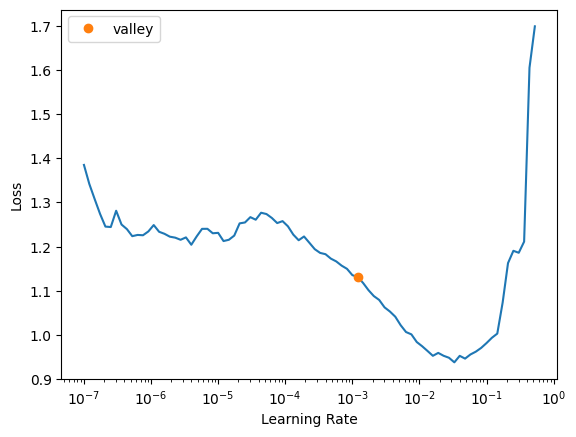

In [ ]:
learn.lr_find()

In [ ]:
learn.fit_one_cycle(5, slice(1e-3, 1e-2))

epoch     train_loss  valid_loss  accuracy  RocAucBinary  time    


TypeError: Exception occured in `Recorder` when calling event `after_batch`:
	unsupported operand type(s) for *: 'AccumMetric' and 'int'

/anaconda/envs/orca/lib/python3.10/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_lo

SuggestedLRs(valley=9.999999747378752e-06)

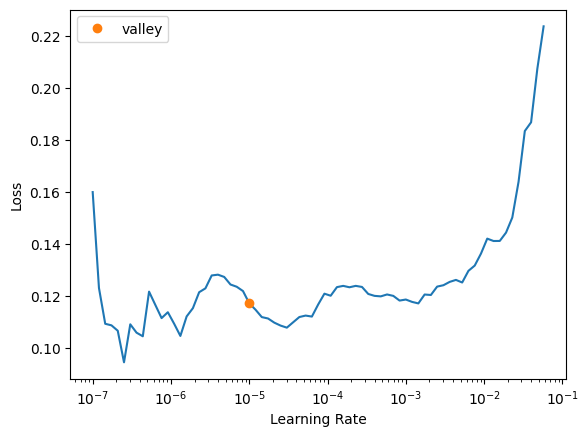

In [ ]:
learn.lr_find()

In [ ]:
learn.fit_one_cycle(5, slice(1e-5, 2e-5))

epoch     train_loss  valid_loss  accuracy  time    
0         0.115998    0.803731    0.718208  03:48                                                                                                      
1         0.123711    0.793501    0.719653  03:45                                                                                                      
2         0.126147    0.824741    0.707473  03:35                                                                                                      
3         0.112814    0.862257    0.685900  03:37                                                                                                      
4         0.120892    0.818847    0.705615  03:35                                                                                                      


The above training achieves an accuracy of over 94% on the validation set.
This is slightly higher than the accuracy reported in `2_FastAI_StarterScript.ipynb`, which was ~93.7%.

### Approach 2: Creating data loaders from scratch

After working on this approach for a bit, I'm having a hard time getting 
it to work. Since we have a working version with the data block, I think
that's sufficient for now. 

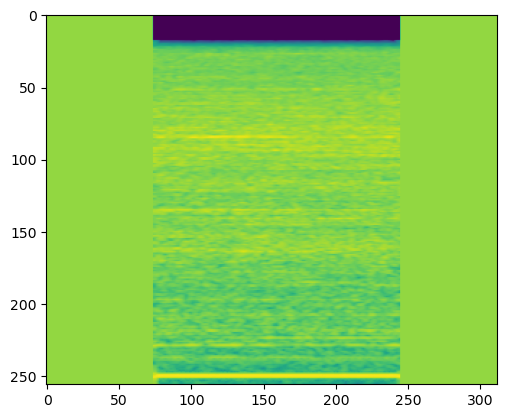

In [ ]:
from torch.utils.data import Dataset
import torchaudio
import torchaudio.transforms as T

class AudioDataset(Dataset):
    def __init__(self, file_paths, target_duration):
        self.file_paths = list(file_paths)
        self.target_duration = target_duration
        self.transform_spec = T.MelSpectrogram(
            f_min=0.0,
            f_max=10000,
            hop_length=256,
            n_fft=2560,
            n_mels=256,
            pad=0,
            win_length=None,
        )
        self.transform_db = T.AmplitudeToDB(top_db=100)
        self.pad_or_crop = PadOrCropTransform(target_duration, hop=256)
        self.cache = {}

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        if path in self.cache:
            return self.cache[path]
        
        signal, sample_rate = torchaudio.load(path)
        spectrogram = self.transform_db(self.transform_spec(signal))
        spectrogram = self.pad_or_crop(spectrogram, sample_rate)
        self.cache[path] = spectrogram
        return spectrogram


dataset = AudioDataset(audio_files, target_duration=4)
show_image(dataset[0])

In [ ]:
from fastai.data.core import DataLoader, DataLoaders
from fastai.vision.all import RandomSplitter

data_folder = Path("./data/train/mldata/all/")
data_files = list(data_folder.rglob("*.wav"))

train_files, valid_files = RandomSplitter(valid_pct=0.2, seed=42)(data_files)

train_ds = AudioDataset(train_files, target_duration=4)
valid_ds = AudioDataset(valid_files, target_duration=4)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_dl = DataLoader(valid_ds, batch_size=64, shuffle=True)

dls = DataLoaders(train_dl, valid_dl)

In [ ]:
# from torchvision import models
# from fastai.vision.all import accuracy, vision_learner

# learn = vision_learner(
#     dls, models.resnet18, metrics=accuracy, n_out=2, normalize=False
# )

## Model Evaluation

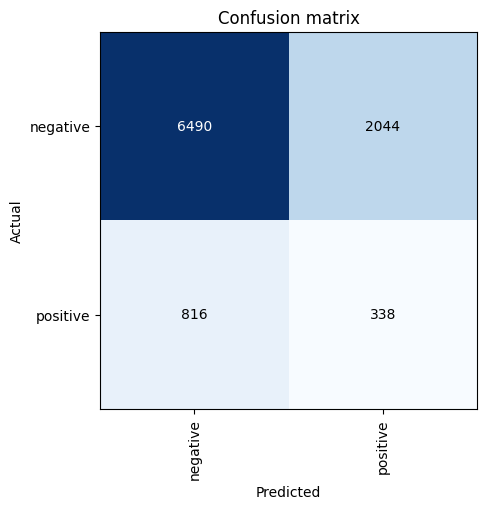

In [ ]:
from fastai.vision.all import ClassificationInterpretation

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(5,5))